In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings("ignore")

plt.rcParams["figure.dpi"] = 120

# Load reviews as demand proxy
reviews = pd.read_csv("../data/processed/reviews_clean.csv", low_memory=False)
reviews["date"] = pd.to_datetime(reviews["date"])
reviews = reviews[reviews["date"].dt.year.between(2019, 2025)]

# Monthly review volume as demand signal
monthly = reviews.groupby(reviews["date"].dt.to_period("M")).size().reset_index()
monthly.columns = ["period", "review_count"]
monthly["date"] = monthly["period"].dt.to_timestamp()
monthly["month_num"] = range(len(monthly))
monthly["month"] = monthly["date"].dt.month
monthly["year"] = monthly["date"].dt.year

print(f"Monthly demand series: {len(monthly)} months")
print(monthly.tail(10).to_string())

Monthly demand series: 81 months
     period  review_count       date  month_num  month  year
71  2024-12         16661 2024-12-01         71     12  2024
72  2025-01         19424 2025-01-01         72      1  2025
73  2025-02         16397 2025-02-01         73      2  2025
74  2025-03         15158 2025-03-01         74      3  2025
75  2025-04         13188 2025-04-01         75      4  2025
76  2025-05         11913 2025-05-01         76      5  2025
77  2025-06         11757 2025-06-01         77      6  2025
78  2025-07         13001 2025-07-01         78      7  2025
79  2025-08         14061 2025-08-01         79      8  2025
80  2025-09          8017 2025-09-01         80      9  2025


Train MAE: 2,709 reviews
Test MAE (2025): 3,561 reviews


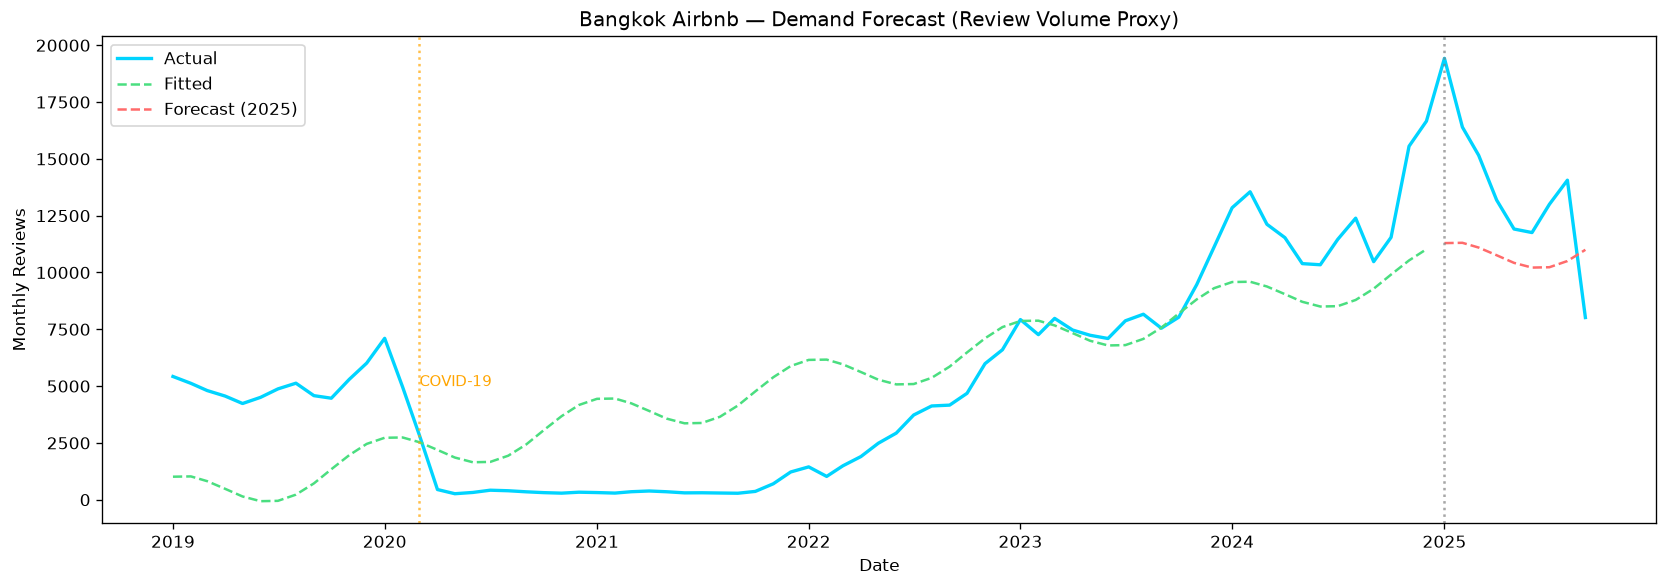


2025 Actual vs Forecast:
         date  review_count  forecast  error
72 2025-01-01         19424     11293   8131
73 2025-02-01         16397     11306   5091
74 2025-03-01         15158     11096   4062
75 2025-04-01         13188     10759   2429
76 2025-05-01         11913     10422   1491
77 2025-06-01         11757     10215   1542
78 2025-07-01         13001     10231   2770
79 2025-08-01         14061     10503   3558
80 2025-09-01          8017     10998  -2981


In [2]:
# --- Decompose Trend + Seasonality ---
from sklearn.linear_model import LinearRegression
import numpy as np

# Add seasonal features
monthly["sin_month"] = np.sin(2 * np.pi * monthly["month"] / 12)
monthly["cos_month"] = np.cos(2 * np.pi * monthly["month"] / 12)

# Features: trend + seasonality
X = monthly[["month_num", "sin_month", "cos_month"]].values
y = monthly["review_count"].values

# Train on 2019-2024, forecast 2025
train = monthly[monthly["year"] < 2025]
test = monthly[monthly["year"] == 2025]

X_train = train[["month_num", "sin_month", "cos_month"]].values
y_train = train["review_count"].values
X_test = test[["month_num", "sin_month", "cos_month"]].values
y_test = test["review_count"].values

model = LinearRegression()
model.fit(X_train, y_train)

train_preds = model.predict(X_train)
test_preds = model.predict(X_test)

train_mae = mean_absolute_error(y_train, train_preds)
test_mae = mean_absolute_error(y_test, test_preds)

print(f"Train MAE: {train_mae:,.0f} reviews")
print(f"Test MAE (2025): {test_mae:,.0f} reviews")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly["date"], monthly["review_count"], 
        label="Actual", color="#00d4ff", linewidth=2)
ax.plot(train["date"], train_preds, 
        label="Fitted", color="#4ade80", linestyle="--")
ax.plot(test["date"], test_preds, 
        label="Forecast (2025)", color="#ff6b6b", linestyle="--")
ax.axvline(pd.Timestamp("2025-01-01"), color="gray", linestyle=":", alpha=0.7)
ax.axvline(pd.Timestamp("2020-03-01"), color="orange", linestyle=":", alpha=0.7)
ax.annotate("COVID-19", xy=(pd.Timestamp("2020-03-01"), 5000),
            color="orange", fontsize=9)
ax.set_title("Bangkok Airbnb — Demand Forecast (Review Volume Proxy)")
ax.set_xlabel("Date")
ax.set_ylabel("Monthly Reviews")
ax.legend()
plt.tight_layout()
plt.savefig("figures/16_demand_forecast.png")
plt.show()

print(f"\n2025 Actual vs Forecast:")
comparison = test[["date","review_count"]].copy()
comparison["forecast"] = test_preds.astype(int)
comparison["error"] = comparison["review_count"] - comparison["forecast"]
print(comparison.to_string())

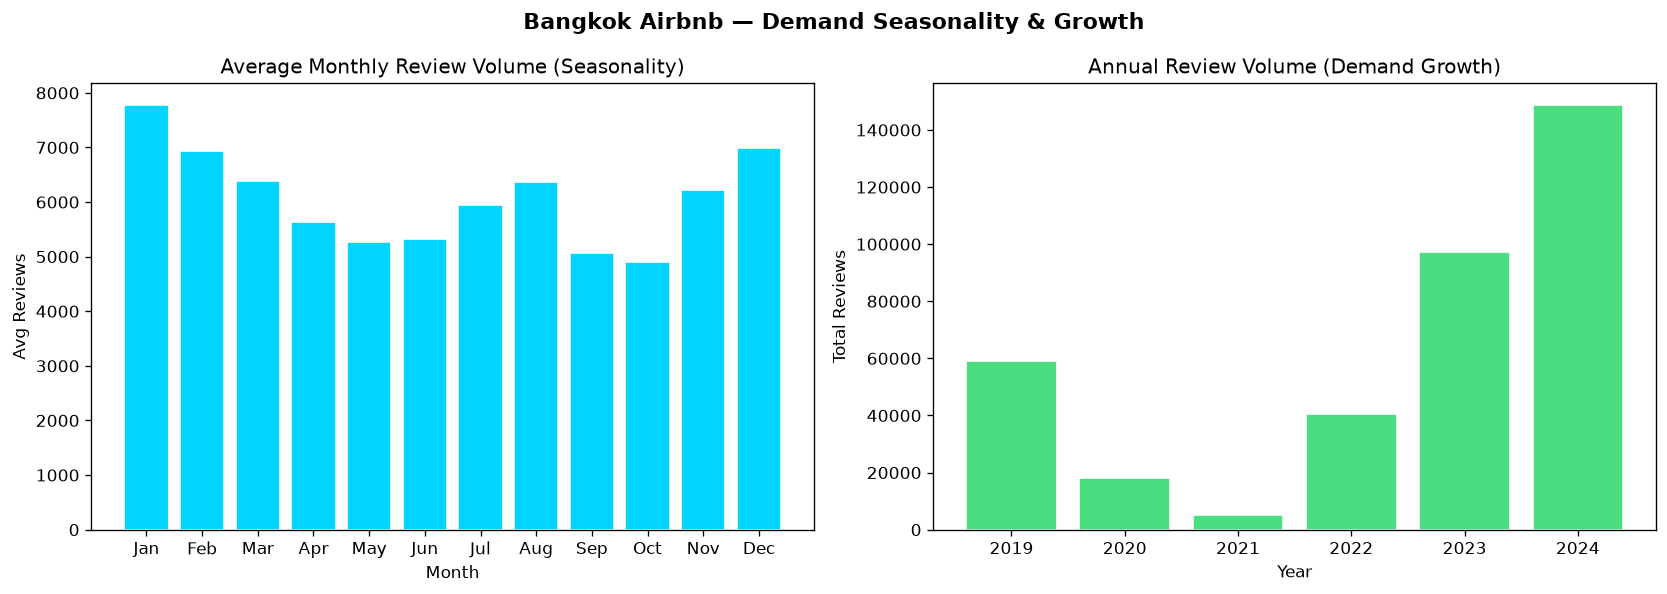

Peak months by avg review volume:
   month_name  review_count
0         Jan   7783.857143
11        Dec   6991.666667
1         Feb   6943.714286
2         Mar   6391.142857
7         Aug   6365.428571
10        Nov   6216.833333
6         Jul   5951.428571
3         Apr   5640.142857
5         Jun   5321.571429
4         May   5267.857143
8         Sep   5059.571429
9         Oct   4901.166667

DEMAND FORECASTING DISCUSSION:
Model: Linear regression with Fourier seasonal features (sin/cos)
Proxy: Monthly review count as booking demand signal

Key findings:
1. 2025 demand significantly exceeds model forecast — 
   market recovery stronger than historical trend predicts
2. Peak demand: Jan, Jul-Aug (tourist high seasons)
3. Trough: Feb-Mar (post-Chinese New Year softness)
4. September 2025 undercounts due to scrape date cutoff

Challenges of demand forecasting in two-sided marketplaces:
1. Supply-side changes affect review counts independently of demand
2. Review rates vary by guest dem

In [3]:
# --- Seasonality Pattern ---
seasonal = monthly.groupby("month")["review_count"].mean().reset_index()
seasonal["month_name"] = ["Jan","Feb","Mar","Apr","May","Jun",
                           "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(seasonal["month_name"], seasonal["review_count"],
            color="#00d4ff", edgecolor="white")
axes[0].set_title("Average Monthly Review Volume (Seasonality)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Avg Reviews")

# Year over year growth
yearly = monthly.groupby("year")["review_count"].sum().reset_index()
yearly = yearly[yearly["year"] < 2025]
axes[1].bar(yearly["year"], yearly["review_count"],
            color="#4ade80", edgecolor="white")
axes[1].set_title("Annual Review Volume (Demand Growth)")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Total Reviews")

plt.suptitle("Bangkok Airbnb — Demand Seasonality & Growth",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("figures/17_seasonality.png")
plt.show()

print("Peak months by avg review volume:")
print(seasonal.sort_values("review_count", ascending=False)[
    ["month_name","review_count"]].to_string())

print("""
DEMAND FORECASTING DISCUSSION:
================================
Model: Linear regression with Fourier seasonal features (sin/cos)
Proxy: Monthly review count as booking demand signal

Key findings:
1. 2025 demand significantly exceeds model forecast — 
   market recovery stronger than historical trend predicts
2. Peak demand: Jan, Jul-Aug (tourist high seasons)
3. Trough: Feb-Mar (post-Chinese New Year softness)
4. September 2025 undercounts due to scrape date cutoff

Challenges of demand forecasting in two-sided marketplaces:
1. Supply-side changes affect review counts independently of demand
2. Review rates vary by guest demographics and platform policies  
3. COVID structural break makes pre-2020 data less relevant
4. New listing entry/exit creates non-stationarity
5. External shocks (political events, exchange rates) not captured

Production approach:
- Use actual booking data (not reviews) as demand signal
- Add external features: holidays, events, exchange rates
- Prophet or SARIMA for proper time-series decomposition
- Separate models per neighbourhood and room type
""")